## الخصائص الثنائية العنصرية المستقلة القوية BRIEF:

### الهدف:
** في هذا الفصل **

* سنرى اسس خوارزمية ال BRIEF.

### النظرية :
نعرف ان خصائص SIFT  تستخدم شعاعاً بطول 128 لموصفاتها , وكذلك وبالتالي الحجم 512 بايت على الاقل بالذاكرة , وكذلك ال SURF تأخذ 256 بايت على الاقل . وانشاء هكذا اشعة لالاف الخصائص لا يعد فعالاً لانه يأخذ الكثير من الذاكرة , وخصوصاً للانظمة المحدودة القدرات او حتى للانظمة المدمجة .  وكلما كبرت الذاكرة , سيستغرق الامر وقتا أطول للمطابقة .

ولكن كل تلك الابعاد قد لا تلزم للمطابقة الفعلية . ويمكننا ان نضغطها باستخدام طرق متعددة مثل PCA , LDA الخ.
وحتى الطرق , الاخرى مثل التمويه باستخدام LSH  (التمويه الحساس محلياً ) يستخدم لتحويل موصفات ال SIFT بالارقام 
العائمة لسلاسل ثنائية . وتستخدم هذه السلاسل الثنائية لمطابقة الخصائص باستخدام مسافات هامنغ . وهذا يعطي تسريعاً أكبر لأن أيجاد مسافة هامنغ , هو مجرد عملية XOR  وعد البتات , وهذا تحديداً سريع جداً بال CPUs  الحديثة مع تعليمات SSE , ولكن هنا علينا إيجاد الموصفات اولاً , وعندها فقط يمكننا تطبيق التمويه hashing  , والذي لايحل مسألتنا الاساسية في الذاكرة .

BRIEF تأتي للمشهد بهذه اللحظة , فهي تقدم اختصاراً لايجاد السلاسل الثنائية مباشرة بدون ايجاد الموصفات . فهي تأخذ قطعة صورة منعمة وتختار مجموعة من nd(x,y)  زوج موقع بطريقة فريدة ( مشروحة بالورقة) . ومن ثم بعض مقارنات شدات البكسلات تتم على أزواج المواقع تلك .
مثلاً , دع اول زوج مواقع يكون p , q  فاذا كانت I(p) < I(q) عندها فان النتيجة 1 والا 0 . وهذا يطبق لكل أزواج مواقع ال nd للحصول على سلسلة بتات ب nd  بعداً.


ال nd هذا قد يكون 128 و 256 و 512 .  وOpenCV تدعم كل من هذا , ولكن افتراضياً ستكون 256 ( OpenCV تمثلها بالبايتات . ولذلك ستكون القيم 16 , 32 , 64 ) . ولذلك حالما تحصل على هذا يمكنك استخدام مسافة هامننغ لمطابقة هذه الموصفات .


نقطة هامة هي ان BRIEF  هي موصفة خصائص , وهي لاتعطي أي وسيلة لاكتشاف الخصائص . لذلك عليك اكتشاف الخصائص بوسيلة أخرى مثل SIFT  او  SURF  الخ . 

توصي الورقة باستعمال CenSurE  لذلك وهي مكتشفات سريعة و BRIEF تعمل بشكل أفضل قليلاً من أجل CenSurE مما هو عليه من أجل SURF .

باختصار , BRIEF , هي موصفات خصائص أسرع طريقة للحساب والمطابقة. وهي تعطي أيضاً معدل تعرف عالي , مالم يكن هناك دوران كبير بالمستوي .



## BRIEF في OpenCV:

البرنامج أدناه يظهر حسابات موصفات BRIEF  مع مساعدة مكتشفات CenSurE . 
( تدعى مكتشفات CenSurE  بمكتشفات STAR  في OpenCV )

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

img = cv2.imread('wt.jpg',0)

# Initiate STAR detector
star = cv2.FeatureDetector_create("STAR")

# Initiate BRIEF extractor
brief = cv2.DescriptorExtractor_create("BRIEF")

# find the keypoints with STAR
kp = star.detect(img,None)

# compute the descriptors with BRIEF
kp, des = brief.compute(img, kp)

print brief.getInt('bytes')
print des.shape

32
(16, 32)


التابع ` brief.getInt('bytes') ` يعطي حجم ال $n_d$ بالبايتات . افتراضياً هو 32. 
الخطوة الثانية هي المطابقة التي ستأتي بفصل لاحق.



### مراجع اضافية :

1. Michael Calonder, Vincent Lepetit, Christoph Strecha, and Pascal Fua, “BRIEF: Binary Robust Independent Elementary Features”, 11th European Conference on Computer Vision (ECCV), Heraklion, Crete. LNCS Springer, September 2010.

2. LSH (Locality Sensitive Hasing) at wikipedia.

## خصائص  ORB:

FAST  الموجهة و  BRIEF  المدورة 

### الهدف:
** في هذا الفصل **

* سنرى أسس خصائص ال ORB.



### النظرية :
كمناصرين لل OpenCV ,  فإن أفضل ما في ORB  أنها جاءت من مختبراتها. 
حيث تم انشاء هذه الخوارزمية من قبل 
Ethan Rublee, Vincent Rabaud, Kurt Konolige and Gary R. Bradski
بورقتهم ORB: بديل فعال ل SIFT و SURF ب 2011

وكما يقول العنوان , فهذه المكتشفات هي بديل جيد ل SIFT  و  SURF   بالكلفة الحسابية , أداء المطابقة وتحديداً الحقوق المحفوظة .
نعم , SIFT ,و  SURF  محفوظي الحقوق ومن المفروض أن تدفع لهم عند الاستخدام , على النقيض من ORB.


ORB  بالجوهر صهر لمكتشفات النقاط FAST , وكذلك BRIEF بموصفاتها , مع الكثير من التعديلات لتحسين الاداء . أولاً نستخدم FAST لايجاد النقاط , ثم نطبق مكتشف هاريس لايجاد أقوى N نقطة بينها , . ويستخدم أيضاً هرماً لايجاد السمات بالقياسات المختلفة . ولكن تبرز المشكلة التالية , وهي ان FAST  لا توجد الاتجاهات , وبالتالي , ماذا سنفعل حيال تباين الاتجاه , لذللك خرج المؤلفون بالتعديل التالي :


سنحسب مركز الشدة المثقلة للقطعة مع الزاوية المحددة بالمركز , اتجاه الشعاع من نقطة الزاوية للمركز يعطينا الدوران . ولتحسين تباين الاتجاه , نحسب العزوم مع x,y والتي يجب ان تكون ضمن منطقة دائرية بقطر r , حيث r هي قياس الرقعة .

أما للموصفات , ف ORB  تستخدم  BRIEF  , ولكن نعلم ان الاخيرة ذات أداء ضعيف بحساب الاتجاهات , ولاي مجموعة سمات من n اختبار ثنائي , بالموضع **(xi , yi)** نعرف مصفوفة 
$$S | (2*n)$$
والتي تحتوي احداثيات تلك البكسلات , ومن ثم باستخدام اتجاهات الرقعة , *t* ونوجد مصفوفة دورانها , ثم ندور **S** للحصول على النسخة المدورة * S(t)*

ORB
تقطع الزاوية لزيادات ل 
$$2\pi /30$$
اي 12 درجة .

وتبني جدول بحث , لنماذج ال BRIEF  المحسوبة . وطالما أن اتجاه النقطة متسق عبر المشاهد , فان المجموعة الصحيحة من النقاط **S(t)**  ستستخدم لحساب موصفها .

ول BRIEF  خاصية مهمة ,ان كل بت من السمة لديه تباين كبير ومتوسط قريب من 0.5 .
ولكن حالما يتم تدويره باتجاه النقطة , يخسر هذه الخاصية ويصبح أكثر توزعاً .
والتباين الشديد يجعل السمة اكثر تميزاً , بما انها ستسجيب بشكل مختلف للمداخيل . وهناك خاصية مرغوبة اخرى , هي عدم طي الاختبارات , وبذلك سيساهم كل اختبار بالنتيجة .
 ولحل كل هذا , تعمل ال ORB  بحثاً جشعاً ضمن كل الاختبارات الثنائية الممكنة لايجاد تلك التي تملك متوسطاً قريباً من 0.5 وتبايناً عالياً . بالاضافة لكونها غير مطوية .  تدعى النتيجة **rBRIEF **  .

ولمطابقة الموصفات , سنستخدم LSH  متعدد المنافذ , وهو تحسين لل LSH  التقليدي . تقول الورقة ان  ORB  أسرع بكثير من SURF , SIFT  , و موصفات ORB  أفضل بعملها مما ل SURF .

 ORB  هي خيار جيد بالات الطاقة المنخفضة , مثلاً , لانشاء بانوراما .
 

## ORB  في  OpenCV 

كالمعتاد سننشئ جسم ORB  بوساطة التابع **()cv2.ORB**  أو باستخدام واجهة feature2d العامة .

ولديه عدد من البارامترات الكيفية , واكثرها فائدة هي `nFeatures`  والتي تحدد العدد الاعظمي من الخصائص المسترجعة (افتراضياً 50) `scoreType` يحدد من يعطي القياس للجودة هل , هاريسس أم FAST  ( هاريس افتراضياً ) . وبارامتر آخر `WTA_K`  يحدد عدد النقاط التي تنتج كل عنصر من موصف  BRIEF  الموجه .
وافتراضياً هو 2 , اي اختر نقطتين بكل مرة .
وبهذه الحالة سنختار `NORM_HAMMING`  كمسافة للمطابقة .
أما اذا كان WTA_K  هو 3 أو 4 و المستخدمة لاعطاء موصفات BRIEF , عندها تعرف مسافة المطابقة ب `NORM_HAMMING2` .

 والتالي هو برنامج بسيط , الذي يظهر استخدام ORB .

See The result below


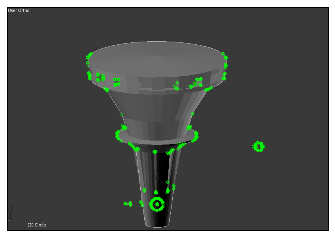

In [30]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

%matplotlib inline

print 'See The result below'

img2 = cv2.imread('wt.jpg')
img = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# Initiate STAR detector
orb = cv2.ORB_create()

# find the keypoints with ORB
kp = orb.detect(img,None)

# compute the descriptors with ORB
kp, des = orb.compute(img, kp)

# draw only keypoints location,not size and orientation
cv2.drawKeypoints(img,kp,img2,color=(0,255,0), flags=0)

# prepare to display
img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)

plt.imshow(img2, cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.show()

### مراجع اضافية :

1. Ethan Rublee, Vincent Rabaud, Kurt Konolige, Gary R. Bradski: ORB: An efficient alternative to SIFT or SURF. ICCV 2011: 2564-2571.


### تمارين 